# 4.1 — Sobol sobre o surrogate SVR de 8 inputs

Calcula índices de Sobol de primeira ordem (S₁) e efeito total (Sₜ) para os 8 inputs do processo,
usando o surrogate SVR baseline (Etapa 2) como função substituta.
Repetido para cada um dos três outputs: ET, M_CH3OH, x_CH3OH.

**Parâmetros fixados (4_PLANO.md):**
- N = 2048 → N × (8 + 2) = 20 480 avaliações por output
- `calc_second_order=False`
- Surrogate: SVR baseline (D-E4-01)

## Seção 1 — Imports e configuração

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

from SALib.sample import saltelli
from SALib.analyze import sobol

# ── Constantes ──────────────────────────────────────────────────────────────
N = 2048

BASE_DIR   = os.path.abspath("../../..")   # raiz do projeto a partir de ARTEFATOS/ETAPA_4/4.1/
ETAPA_2    = os.path.join(BASE_DIR, "ARTEFATOS", "ETAPA_2")
ETAPA_0    = os.path.join(BASE_DIR, "ARTEFATOS", "ETAPA_0", "processed")
ETAPA_4    = os.path.join(BASE_DIR, "ARTEFATOS", "ETAPA_4", "4.1")

# ── Definição do problema (8 inputs, faixas físicas de CLAUDE.md) ────────────
problem_8 = {
    "num_vars": 8,
    "names":   ["P1", "T1", "T2", "RRC1", "BRC1", "RRC2", "BRC2", "RFF"],
    "bounds":  [
        [50,   100],   # P1  — pressão do reator (bar)
        [200,  300],   # T1  — temperatura do reator (°C)
        [85,    95],   # T2  — temperatura entrada coluna destilação (°C)
        [1,     10],   # RRC1 — razão de refluxo coluna 1
        [0.5,   10],   # BRC1 — razão de boil-up coluna 1
        [1,     10],   # RRC2 — razão de refluxo coluna 2
        [0.5,   10],   # BRC2 — razão de boil-up coluna 2
        [0.01, 0.25],  # RFF  — fração de purga
    ],
}

OUTPUTS = ["ET", "M_CH3OH", "x_CH3OH"]

print(f"N = {N}  →  {N * (problem_8['num_vars'] + 2):,} avaliações por output")
print(f"Problema: {problem_8['num_vars']} inputs — {problem_8['names']}")

## Seção 2 — Carga dos modelos e scalers

In [3]:
# ── Modelos SVR baseline ─────────────────────────────────────────────────────
models = {}
for out in OUTPUTS:
    path = os.path.join(ETAPA_2, "SVR", out, "model.pkl")
    models[out] = joblib.load(path)
    print(f"Carregado SVR/{out}: {path}")

# ── Scalers de X (min-max, shape (8,)) ───────────────────────────────────────
scaler_X_min   = np.load(os.path.join(ETAPA_0, "scaler_X_min.npy"))
scaler_X_scale = np.load(os.path.join(ETAPA_0, "scaler_X_scale.npy"))

print(f"\nscaler_X_min   shape: {scaler_X_min.shape}")
print(f"scaler_X_scale shape: {scaler_X_scale.shape}")
print(f"scaler_X_min   = {scaler_X_min}")
print(f"scaler_X_scale = {scaler_X_scale}")

Carregado SVR/ET: /Users/lorenzoferreira/Documents/UFRGS/TCC_SBO/ARTEFATOS/ETAPA_2/SVR/ET/model.pkl
Carregado SVR/M_CH3OH: /Users/lorenzoferreira/Documents/UFRGS/TCC_SBO/ARTEFATOS/ETAPA_2/SVR/M_CH3OH/model.pkl
Carregado SVR/x_CH3OH: /Users/lorenzoferreira/Documents/UFRGS/TCC_SBO/ARTEFATOS/ETAPA_2/SVR/x_CH3OH/model.pkl

scaler_X_min   shape: (8,)
scaler_X_scale shape: (8,)
scaler_X_min   = [5.00277030e+01 2.00119416e+02 8.50023229e+01 1.00675628e+00
 5.02164445e-01 1.00059745e+00 5.01838760e-01 1.00071268e-02]
scaler_X_scale = [49.96782685 99.84375386  9.99290816  8.9864509   9.49155418  8.99763685
  9.49631006  0.23988401]


## Seção 3 — Geração das amostras de Saltelli

In [4]:
# Gerar amostras no espaço físico
# Nota: parâmetro `seed` omitido — não disponível na versão instalada do SALib.
# A sequência quasi-aleatória de Sobol é determinística, portanto reprodutível.
param_values = saltelli.sample(problem_8, N, calc_second_order=False)

expected_rows = N * (problem_8["num_vars"] + 2)
print(f"Shape das amostras (espaço físico): {param_values.shape}")
print(f"Esperado: ({expected_rows}, {problem_8['num_vars']})")
assert param_values.shape == (expected_rows, problem_8["num_vars"]), "Shape inesperado!"

# Normalizar para o espaço [0, 1] em que os SVRs foram treinados
# X_norm = (X - min) / scale
param_values_norm = (param_values - scaler_X_min) / scaler_X_scale

print(f"Shape normalizado: {param_values_norm.shape}")
print(f"Range norm — min: {param_values_norm.min():.4f}, max: {param_values_norm.max():.4f}")

Shape das amostras (espaço físico): (20480, 8)
Esperado: (20480, 8)
Shape normalizado: (20480, 8)
Range norm — min: -0.0010, max: 1.0005


/var/folders/yp/4mc_b2c54g7fpgchq00gm31c0000gn/T/ipykernel_16466/134934280.py:4: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem_8, N, calc_second_order=False)


## Seção 4 — Cálculo dos índices por output

In [5]:
records = []

for out in OUTPUTS:
    print(f"\n── Output: {out} ──")

    # 1. Predições do surrogate
    Y = models[out].predict(param_values_norm)
    print(f"   Y shape: {Y.shape}  |  mean={Y.mean():.4f}  std={Y.std():.4f}")

    # 2. Análise de Sobol
    # Nota: `seed` omitido — idem Seção 3
    Si = sobol.analyze(problem_8, Y, calc_second_order=False, conf_level=0.95)

    # 3. Montar DataFrame parcial
    for i, feat in enumerate(problem_8["names"]):
        records.append({
            "output":   out,
            "feature":  feat,
            "S1":       Si["S1"][i],
            "S1_conf":  Si["S1_conf"][i],
            "ST":       Si["ST"][i],
            "ST_conf":  Si["ST_conf"][i],
        })

    # Resumo rápido
    for i, feat in enumerate(problem_8["names"]):
        print(f"   {feat:6s}  S1={Si['S1'][i]:.4f} ± {Si['S1_conf'][i]:.4f}   "
              f"ST={Si['ST'][i]:.4f} ± {Si['ST_conf'][i]:.4f}")

print("\nCálculo concluído.")


── Output: ET ──
   Y shape: (20480,)  |  mean=0.2905  std=0.1682
   P1      S1=-0.0032 ± 0.0052   ST=0.0058 ± 0.0008
   T1      S1=0.0145 ± 0.0214   ST=0.0864 ± 0.0108
   T2      S1=0.0011 ± 0.0043   ST=0.0046 ± 0.0011
   RRC1    S1=-0.0020 ± 0.0091   ST=0.0265 ± 0.0032
   BRC1    S1=0.3178 ± 0.0319   ST=0.3777 ± 0.0314
   RRC2    S1=0.0888 ± 0.0198   ST=0.1296 ± 0.0137
   BRC2    S1=0.0061 ± 0.0068   ST=0.0126 ± 0.0017
   RFF     S1=0.4367 ± 0.0419   ST=0.5005 ± 0.0383

── Output: M_CH3OH ──
   Y shape: (20480,)  |  mean=0.4195  std=0.2196
   P1      S1=0.0052 ± 0.0075   ST=0.0133 ± 0.0017
   T1      S1=0.1993 ± 0.0302   ST=0.2354 ± 0.0196
   T2      S1=-0.0011 ± 0.0027   ST=0.0026 ± 0.0003
   RRC1    S1=0.1583 ± 0.0315   ST=0.2393 ± 0.0186
   BRC1    S1=0.2136 ± 0.0307   ST=0.2635 ± 0.0227
   RRC2    S1=0.0469 ± 0.0153   ST=0.0667 ± 0.0065
   BRC2    S1=0.0602 ± 0.0165   ST=0.0803 ± 0.0076
   RFF     S1=0.1983 ± 0.0277   ST=0.2376 ± 0.0182

── Output: x_CH3OH ──
   Y shape: (20480,

## Seção 5 — Tabela consolidada e validação

In [6]:
df_4_1 = pd.DataFrame(records, columns=["output", "feature", "S1", "S1_conf", "ST", "ST_conf"])

print(f"Shape: {df_4_1.shape}  (esperado: 24 linhas)")
print(df_4_1.to_string(index=False, float_format="{:.4f}".format))

# ── Validações ───────────────────────────────────────────────────────────────
assert df_4_1.shape[0] == 24, f"Esperado 24 linhas, obtido {df_4_1.shape[0]}"
assert df_4_1.isnull().sum().sum() == 0, "NaN detectado!"

# Propriedade Sobol: soma de S1 por output ≤ 1
for out in OUTPUTS:
    s1_sum = df_4_1.loc[df_4_1["output"] == out, "S1"].sum()
    print(f"Σ S1 ({out}): {s1_sum:.4f}  {'OK' if s1_sum <= 1.05 else 'ALERTA'}")

# ST ≥ S1 (tolerância numérica de 1e-6)
violacoes = df_4_1[df_4_1["ST"] < df_4_1["S1"] - 1e-6]
if violacoes.empty:
    print("ST ≥ S1 para todos os 24 pares: OK")
else:
    print(f"ALERTA: {len(violacoes)} pares com ST < S1:")
    print(violacoes)

# ── Salvar CSV ───────────────────────────────────────────────────────────────
out_csv = os.path.join(ETAPA_4, "4.1_sobol_8inputs_resultados.csv")
df_4_1.to_csv(out_csv, index=False)
print(f"\nSalvo: {out_csv}")

Shape: (24, 6)  (esperado: 24 linhas)
 output feature      S1  S1_conf     ST  ST_conf
     ET      P1 -0.0032   0.0052 0.0058   0.0008
     ET      T1  0.0145   0.0214 0.0864   0.0108
     ET      T2  0.0011   0.0043 0.0046   0.0011
     ET    RRC1 -0.0020   0.0091 0.0265   0.0032
     ET    BRC1  0.3178   0.0319 0.3777   0.0314
     ET    RRC2  0.0888   0.0198 0.1296   0.0137
     ET    BRC2  0.0061   0.0068 0.0126   0.0017
     ET     RFF  0.4367   0.0419 0.5005   0.0383
M_CH3OH      P1  0.0052   0.0075 0.0133   0.0017
M_CH3OH      T1  0.1993   0.0302 0.2354   0.0196
M_CH3OH      T2 -0.0011   0.0027 0.0026   0.0003
M_CH3OH    RRC1  0.1583   0.0315 0.2393   0.0186
M_CH3OH    BRC1  0.2136   0.0307 0.2635   0.0227
M_CH3OH    RRC2  0.0469   0.0153 0.0667   0.0065
M_CH3OH    BRC2  0.0602   0.0165 0.0803   0.0076
M_CH3OH     RFF  0.1983   0.0277 0.2376   0.0182
x_CH3OH      P1  0.0019   0.0050 0.0091   0.0016
x_CH3OH      T1  0.0031   0.0088 0.0278   0.0040
x_CH3OH      T2 -0.0081   0.005

## Seção 6 — Visualizações (barplots S₁ e Sₜ por output)

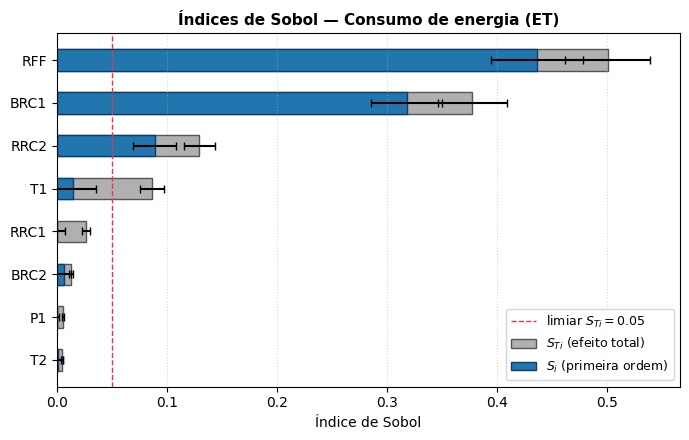

Salvo: /Users/lorenzoferreira/Documents/UFRGS/TCC_SBO/ARTEFATOS/ETAPA_4/4.1_sobol_8inputs_barplot_ET.png


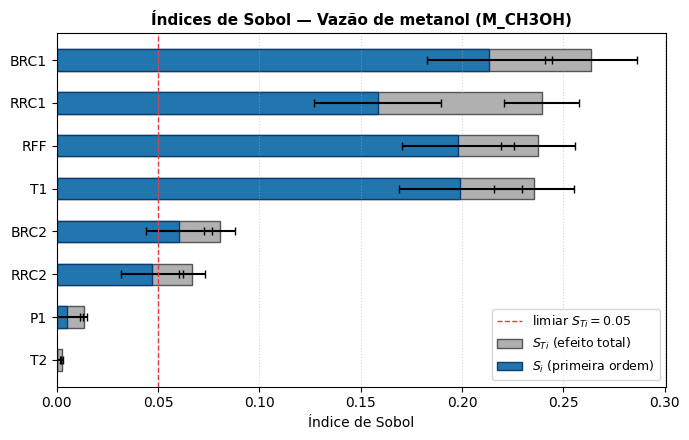

Salvo: /Users/lorenzoferreira/Documents/UFRGS/TCC_SBO/ARTEFATOS/ETAPA_4/4.1_sobol_8inputs_barplot_M.png


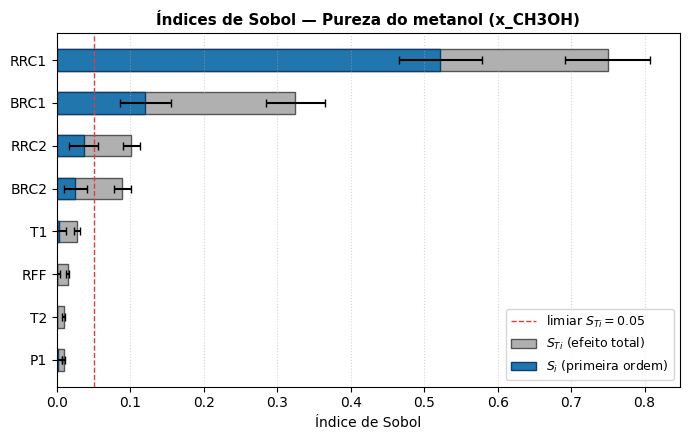

Salvo: /Users/lorenzoferreira/Documents/UFRGS/TCC_SBO/ARTEFATOS/ETAPA_4/4.1_sobol_8inputs_barplot_x.png


In [7]:
LABEL_MAP = {
    "ET":      "Consumo de energia (ET)",
    "M_CH3OH": "Vazão de metanol (M_CH3OH)",
    "x_CH3OH": "Pureza do metanol (x_CH3OH)",
}
FILE_MAP = {
    "ET":      "4.1_sobol_8inputs_barplot_ET.png",
    "M_CH3OH": "4.1_sobol_8inputs_barplot_M.png",
    "x_CH3OH": "4.1_sobol_8inputs_barplot_x.png",
}

for out in OUTPUTS:
    df_out = (
        df_4_1[df_4_1["output"] == out]
        .sort_values("ST", ascending=True)   # maior ST no topo
        .reset_index(drop=True)
    )

    feats  = df_out["feature"].tolist()
    s1     = df_out["S1"].values
    st     = df_out["ST"].values
    s1_err = df_out["S1_conf"].values
    st_err = df_out["ST_conf"].values
    y_pos  = np.arange(len(feats))

    fig, ax = plt.subplots(figsize=(7, 4.5))

    # ST em cinza (fundo)
    ax.barh(y_pos, st, xerr=st_err, height=0.5,
            color="#b0b0b0", edgecolor="#555", capsize=3,
            label="$S_{Ti}$ (efeito total)")

    # S1 em azul (sobreposto)
    ax.barh(y_pos, s1, xerr=s1_err, height=0.5,
            color="#2176ae", edgecolor="#0d3d6e", capsize=3,
            label="$S_i$ (primeira ordem)")

    # Linha de referência — importância mínima
    ax.axvline(0.05, color="#e63946", linestyle="--", linewidth=1,
               label="limiar $S_{Ti}=0.05$")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(feats, fontsize=10)
    ax.set_xlabel("Índice de Sobol", fontsize=10)
    ax.set_title(f"Índices de Sobol — {LABEL_MAP[out]}", fontsize=11, fontweight="bold")
    ax.set_xlim(left=0)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(axis="x", linestyle=":", alpha=0.5)

    plt.tight_layout()
    fig_path = os.path.join(ETAPA_4, FILE_MAP[out])
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Salvo: {fig_path}")

## Resumo de validação

In [8]:
print("=" * 55)
print("CHECKLIST DE VALIDAÇÃO — 4.1")
print("=" * 55)

checks = [
    ("CSV com 24 linhas",       df_4_1.shape[0] == 24),
    ("Sem NaN",                 df_4_1.isnull().sum().sum() == 0),
    ("ST ≥ S1 em todos os pares",
     (df_4_1["ST"] >= df_4_1["S1"] - 1e-6).all()),
]

# P1 e T2 com ST baixo (< 0.25) para pelo menos um output — resultado esperado
p1_max_st = df_4_1[df_4_1["feature"] == "P1"]["ST"].max()
t2_max_st = df_4_1[df_4_1["feature"] == "T2"]["ST"].max()
checks.append((f"P1 ST_max = {p1_max_st:.4f} (esperado baixo)", p1_max_st < 0.40))
checks.append((f"T2 ST_max = {t2_max_st:.4f} (esperado baixo)", t2_max_st < 0.40))

for descr, ok in checks:
    status = "[OK]" if ok else "[ALERTA]"
    print(f"  {status}  {descr}")

print("=" * 55)
print("Artefatos gerados:")
print(f"  CSV  → {out_csv}")
for out in OUTPUTS:
    print(f"  PNG  → {os.path.join(ETAPA_4, FILE_MAP[out])}")

CHECKLIST DE VALIDAÇÃO — 4.1
  [OK]  CSV com 24 linhas
  [OK]  Sem NaN
  [OK]  ST ≥ S1 em todos os pares
  [OK]  P1 ST_max = 0.0133 (esperado baixo)
  [OK]  T2 ST_max = 0.0092 (esperado baixo)
Artefatos gerados:
  CSV  → /Users/lorenzoferreira/Documents/UFRGS/TCC_SBO/ARTEFATOS/ETAPA_4/4.1_sobol_8inputs_resultados.csv
  PNG  → /Users/lorenzoferreira/Documents/UFRGS/TCC_SBO/ARTEFATOS/ETAPA_4/4.1_sobol_8inputs_barplot_ET.png
  PNG  → /Users/lorenzoferreira/Documents/UFRGS/TCC_SBO/ARTEFATOS/ETAPA_4/4.1_sobol_8inputs_barplot_M.png
  PNG  → /Users/lorenzoferreira/Documents/UFRGS/TCC_SBO/ARTEFATOS/ETAPA_4/4.1_sobol_8inputs_barplot_x.png
